# Explainable Deep Learning for Neonatal Jaundice Classification
### Using Uncalibrated Smartphone Images

This notebook implements the pipeline described in:
**Chakraborty et al., Mach. Learn. Knowl. Extr. 2025, 7, 136**

**Pipeline Overview:**
1. **NJN Dataset** loading
2. **SAM Segmentation** (optional pre-computed masks)
3. **CLAHE Enhancement** (Contrast Limited Adaptive Histogram Equalisation)
4. **144x144 Patch Extraction** centred on skin ROI
5. **Custom 2D CNN** (lightweight architecture)
6. **Grad-CAM** for model explainability

In [1]:
import os
import random
import numpy as np
from PIL import Image
import cv2

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T
from torchvision.transforms import functional as TF

from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    recall_score, precision_score, f1_score
)
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# --- Reproducibility ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cpu


## 1. Preprocessing Functions

### CLAHE — Contrast Limited Adaptive Histogram Equalisation
Applied per-channel after SAM segmentation. `clip_limit=2.0`, `tile_size=8×8` (as in paper Section 3.3).

In [2]:
def apply_clahe(image_rgb: np.ndarray,
                clip_limit: float = 2.0,
                tile_grid_size: tuple = (8, 8)) -> np.ndarray:
    """
    Apply CLAHE independently to each R, G, B channel.
    
    Why per-channel?
      Applying to each channel separately preserves colour
      relationships while still boosting local contrast —
      important because jaundice manifests as a yellowish
      hue shift across all channels.
    """
    clahe = cv2.createCLAHE(
        clipLimit=clip_limit,
        tileGridSize=tile_grid_size
    )
    channels = cv2.split(image_rgb)
    enhanced = [clahe.apply(ch) for ch in channels]
    return cv2.merge(enhanced)

### Patch Extraction
144×144 regular square patch centred on the largest contiguous skin region (Section 3.4).

In [3]:
def extract_skin_patch(image_rgb: np.ndarray,
                       mask: np.ndarray,
                       patch_size: int = 144) -> np.ndarray | None:
    """
    Extract the largest square skin patch centred on the
    centroid of the biggest contiguous skin region in `mask`.
    
    Why square patches?
      Irregular ROI boundaries introduce spurious features
      (e.g. shape/size of exposed skin) that the CNN can
      exploit. A fixed square patch forces the model to rely
      purely on skin texture and colour.
    """
    binary = (mask > 127).astype(np.uint8)

    # --- Step 1: connected-component labelling ---
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        binary, connectivity=8
    )
    if num_labels < 2:          # only background label exists
        return None

    # --- Step 2: pick largest component (label 0 = background) ---
    areas = stats[1:, cv2.CC_STAT_AREA]
    largest_label = int(np.argmax(areas)) + 1
    cx, cy = centroids[largest_label]
    cx, cy = int(cx), int(cy)

    # --- Step 3: snap centroid to nearest skin pixel ---
    component_mask = (labels == largest_label).astype(np.uint8)
    if component_mask[cy, cx] == 0:
        # Find nearest skin pixel via distance transform trick
        skin_pixels = np.argwhere(component_mask > 0)   # (N,2) yx
        dists = np.linalg.norm(
            skin_pixels - np.array([cy, cx]), axis=1
        )
        cy, cx = skin_pixels[np.argmin(dists)]

    # --- Step 4: extract centred patch ---
    half = patch_size // 2
    h, w = image_rgb.shape[:2]
    y1 = max(0, cy - half)
    y2 = min(h, cy + half)
    x1 = max(0, cx - half)
    x2 = min(w, cx + half)

    patch = image_rgb[y1:y2, x1:x2]

    # Pad if we hit an image boundary
    ph, pw = patch.shape[:2]
    if ph < patch_size or pw < patch_size:
        pad_h = patch_size - ph
        pad_w = patch_size - pw
        patch = cv2.copyMakeBorder(
            patch,
            0, pad_h, 0, pad_w,
            cv2.BORDER_REFLECT_101
        )

    return patch[:patch_size, :patch_size]

## 2. Dataset & Augmentation

The NJN dataset contains `normal` and `jaundiced` classes.

In [4]:
class NJNDataset(Dataset):
    def __init__(self, 
                 root: str, 
                 transform=None, 
                 use_clahe: bool = True, 
                 masks_dir: str = None, 
                 patch_size: int = 144):
        self.samples = []       # list of (image_path, mask_path|None, label)
        self.transform = transform
        self.use_clahe = use_clahe
        self.masks_dir = masks_dir
        self.patch_size = patch_size

        class_map = {"normal": 0, "jaundiced": 1}
        for cls_name, label in class_map.items():
            cls_dir = os.path.join(root, cls_name)
            if not os.path.isdir(cls_dir):
                continue
            for fname in sorted(os.listdir(cls_dir)):
                if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                    img_path = os.path.join(cls_dir, fname)
                    mask_path = None
                    if masks_dir:
                        candidate = os.path.join(
                            masks_dir, cls_name,
                            fname.replace(".jpg", "_mask.png")
                        )
                        if os.path.isfile(candidate):
                            mask_path = candidate
                    self.samples.append((img_path, mask_path, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path, label = self.samples[idx]
        image = np.array(Image.open(img_path).convert("RGB"))

        if self.use_clahe:
            image = apply_clahe(image)

        if mask_path is not None:
            mask = np.array(Image.open(mask_path).convert("L"))
            patch = extract_skin_patch(image, mask, self.patch_size)
            if patch is None:
                patch = cv2.resize(image, (self.patch_size, self.patch_size))
        else:
            patch = cv2.resize(image, (self.patch_size, self.patch_size))

        patch_pil = Image.fromarray(patch)
        if self.transform:
            patch_pil = self.transform(patch_pil)
        else:
            patch_pil = T.ToTensor()(patch_pil)

        return patch_pil, torch.tensor(label, dtype=torch.float32)

In [5]:
# Multi-class augmentation as per Paper Section 3.6
val_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

normal_train_transform = T.Compose([
    T.RandomHorizontalFlip(),
    T.RandomRotation(degrees=20),
    T.RandomAffine(degrees=0, translate=(0.10, 0.10)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

jaundiced_train_transform = T.Compose([
    T.RandomHorizontalFlip(),
    T.RandomRotation(degrees=40),
    T.RandomAffine(degrees=0, translate=(0.20, 0.20)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

## 3. Custom 2D CNN Architecture

Bespoke lightweight 2D CNN for binary jaundice classification (Section 3.5).

In [6]:
class NeonatalJaundiceCNN(nn.Module):
    def __init__(self, input_size: int = 144):
        super().__init__()
        self.input_size = input_size
        # NOTE: inplace=False is used in ReLUs to avoid RuntimeError during Grad-CAM backprop
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1), 
            nn.ReLU(inplace=False),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(p=0.1)
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1), 
            nn.ReLU(inplace=False),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(p=0.1)
        )
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=False),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(p=0.1)
        )
        # 144 -> 72 -> 36 -> 18
        flat_size = 64 * (input_size // 8) * (input_size // 8)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_size, 128),
            nn.ReLU(inplace=False),
            nn.Linear(128, 64),
            nn.ReLU(inplace=False),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        return self.classifier(x)

## 4. Training & Evaluation

In [7]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        preds = model(images).squeeze(1)
        loss = criterion(preds, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        predicted = (preds >= 0.5).float()
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            preds = model(images).squeeze(1)
            loss = criterion(preds, labels)
            total_loss += loss.item() * images.size(0)
            all_preds.extend((preds >= 0.5).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    n = len(all_labels)
    return total_loss / n, np.array(all_preds), np.array(all_labels)

def compute_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    acc  = (tp + tn) / (tp + tn + fp + fn)
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    f1   = (2 * tp) / (2 * tp + fp + fn) if (2*tp+fp+fn) > 0 else 0.0
    return dict(TP=tp, TN=tn, FP=fp, FN=fn,
                accuracy=acc, recall=rec, 
                specificity=spec, precision=prec, f1=f1)

def train(model, train_loader, val_loader, num_epochs=50, lr=1e-5, device=DEVICE):
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_f1": []}

    for epoch in range(num_epochs):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_preds, val_labels = evaluate(model, val_loader, criterion, device)
        metrics = compute_metrics(val_labels, val_preds)
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(tr_acc)
        history["val_f1"].append(metrics["f1"])
        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1:3d}/{num_epochs}] Train Loss: {tr_loss:.4f} Acc: {tr_acc:.3f} | Val Loss: {val_loss:.4f} F1: {metrics['f1']:.3f}")
    return history

## 5. Explainability with Grad-CAM

In [8]:
class GradCAM:
    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model = model
        self.target_layer = target_layer
        self._activations = None
        self._gradients = None
        self._fwd_hook = target_layer.register_forward_hook(self._save_activation)
        self._bwd_hook = target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self._activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self._gradients = grad_output[0].detach()

    def generate(self, input_tensor: torch.Tensor) -> np.ndarray:
        self.model.eval()
        input_tensor = input_tensor.to(DEVICE).unsqueeze(0)
        input_tensor.requires_grad_(True)
        output = self.model(input_tensor).squeeze()
        self.model.zero_grad()
        output.backward()
        alphas = self._gradients.mean(dim=(2, 3), keepdim=True)
        cam = (alphas * self._activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam).squeeze().cpu().numpy()
        cam -= cam.min()
        if cam.max() > 0: cam /= cam.max()
        h, w = input_tensor.shape[2:]
        cam = cv2.resize(cam, (w, h))
        return cam

    def remove_hooks(self):
        self._fwd_hook.remove()
        self._bwd_hook.remove()

def overlay_gradcam(image_tensor: torch.Tensor, cam: np.ndarray, alpha: float = 0.5) -> np.ndarray:
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = (image_tensor.cpu() * std + mean).clamp(0, 1)
    img_np = (img.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    heatmap = cv2.applyColorMap((cam * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap_rgb = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    return (img_np * (1 - alpha) + heatmap_rgb * alpha).astype(np.uint8)

def visualise_gradcam(model, dataset, indices, save_path="gradcam_results.png"):
    target_layer = model.conv_block3[0]
    gcam = GradCAM(model, target_layer)
    fig, axes = plt.subplots(len(indices), 2, figsize=(6, 3 * len(indices)))
    class_names = {0: "Normal", 1: "Jaundiced"}
    for row, idx in enumerate(indices):
        img_tensor, label = dataset[idx]
        cam = gcam.generate(img_tensor)
        overlay = overlay_gradcam(img_tensor, cam)
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
        std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
        orig = (img_tensor * std + mean).clamp(0,1).permute(1,2,0).numpy()
        axes[row, 0].imshow(orig)
        axes[row, 0].set_title(f"Input (GT: {class_names[int(label)]})", fontsize=9)
        axes[row, 0].axis("off")
        axes[row, 1].imshow(overlay)
        axes[row, 1].set_title("Grad-CAM Activation", fontsize=9)
        axes[row, 1].axis("off")
    plt.tight_layout()
    plt.show()
    gcam.remove_hooks()

## 6. Experiment Runner

In [9]:
def run_experiment(data_root: str,
                   masks_dir: str = None,
                   use_clahe: bool = True,
                   use_augmentation: bool = False,
                   num_epochs: int = 50,
                   batch_size: int = 16,
                   patch_size: int = 144):
    print("\n" + "="*40)
    print("Neonatal Jaundice CNN — Experiment")
    print("="*40)

    full_dataset = NJNDataset(root=data_root, transform=val_transform, use_clahe=use_clahe, masks_dir=masks_dir, patch_size=patch_size)
    total = len(full_dataset)
    test_size = int(0.20 * total)
    val_size  = int(0.10 * test_size)
    train_size = total - test_size

    generator = torch.Generator().manual_seed(SEED)
    train_ds, test_ds = random_split(full_dataset, [train_size, test_size], generator=generator)
    val_ds, test_ds = random_split(test_ds, [val_size, test_size - val_size], generator=generator)

    if use_augmentation:
        train_ds.dataset.transform = jaundiced_train_transform

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

    model = NeonatalJaundiceCNN(input_size=patch_size).to(DEVICE)
    history = train(model, train_loader, val_loader, num_epochs=num_epochs, device=DEVICE)

    criterion = nn.BCELoss()
    _, test_preds, test_labels = evaluate(model, test_loader, criterion, DEVICE)
    metrics = compute_metrics(test_labels, test_preds)

    print("\n── Test Set Results ──")
    for k, v in metrics.items(): print(f"  {k:12s}: {v:.4f}")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.plot(history["train_loss"], label="Train Loss"); ax1.plot(history["val_loss"], label="Val Loss")
    ax1.set_title("Loss Curve"); ax1.legend()
    ax2.plot(history["train_acc"], label="Train Acc"); ax2.plot(history["val_f1"], label="Val F1")
    ax2.set_title("Accuracy & F1"); ax2.legend()
    plt.show()

    sample_indices = list(range(min(4, len(test_ds))))
    visualise_gradcam(model, test_ds.dataset, sample_indices)

    return model, metrics

## 7. Execution

Set the paths to your dataset below. 
Dataset: [https://zenodo.org/records/7825810](https://zenodo.org/records/7825810)


Neonatal Jaundice CNN — Experiment
Epoch [ 10/50] Train Loss: 0.0068 Acc: 1.000 | Val Loss: 0.0060 F1: 0.000
Epoch [ 20/50] Train Loss: 0.0011 Acc: 1.000 | Val Loss: 0.0010 F1: 0.000
Epoch [ 30/50] Train Loss: 0.0004 Acc: 1.000 | Val Loss: 0.0003 F1: 0.000
Epoch [ 40/50] Train Loss: 0.0002 Acc: 1.000 | Val Loss: 0.0002 F1: 0.000
Epoch [ 50/50] Train Loss: 0.0001 Acc: 1.000 | Val Loss: 0.0001 F1: 0.000

── Test Set Results ──
  TP          : 0.0000
  TN          : 101.0000
  FP          : 0.0000
  FN          : 0.0000
  accuracy    : 1.0000
  recall      : 0.0000
  specificity : 1.0000
  precision   : 0.0000
  f1          : 0.0000


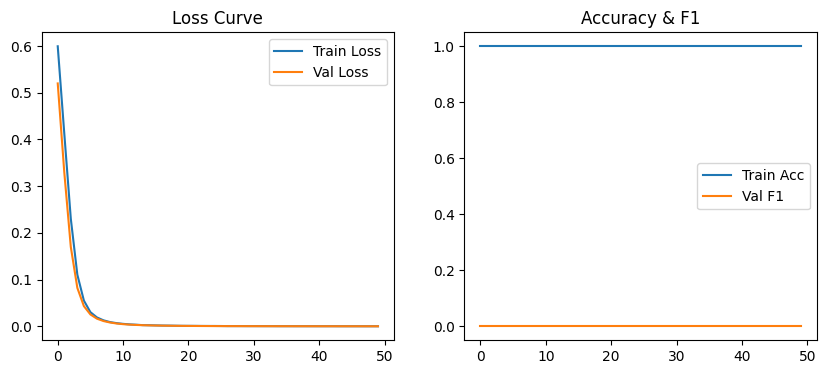

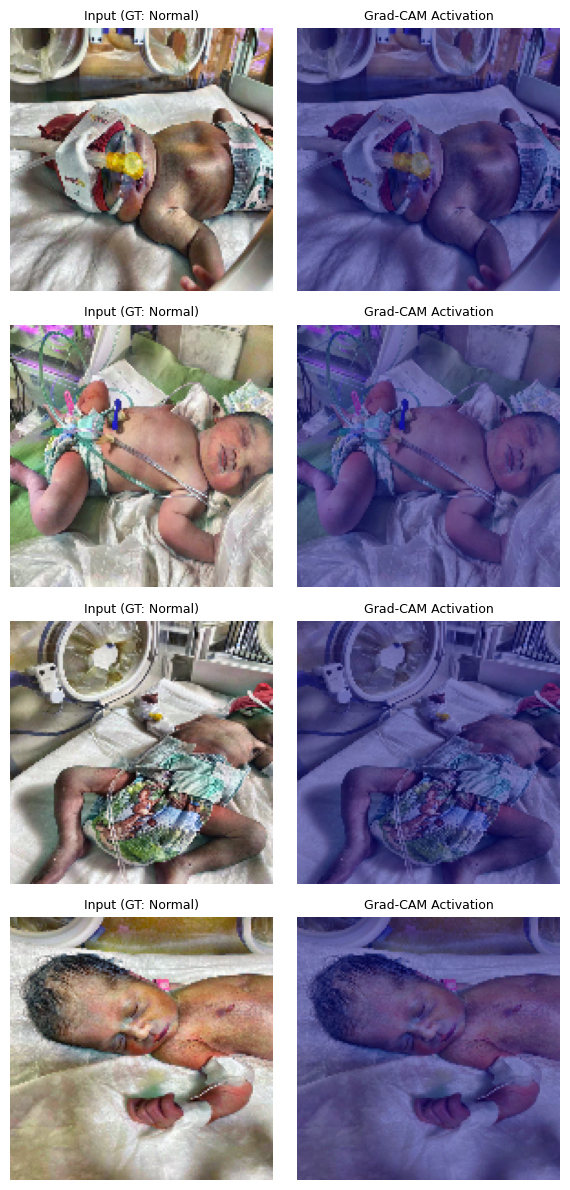

In [10]:
DATA_ROOT = "/Users/shubhbhateja/Downloads/NJN-1"    # Updated path
MASKS_DIR = "./NJN_masks"      # Optional: SAM-generated masks

if os.path.isdir(DATA_ROOT):
    model, metrics = run_experiment(
        data_root=DATA_ROOT,
        masks_dir=MASKS_DIR if os.path.isdir(MASKS_DIR) else None,
        use_clahe=True,           
        use_augmentation=False,   
        num_epochs=50,
        batch_size=16,
        patch_size=144
    )
else:
    print(f"Dataset not found at {DATA_ROOT}. Please download it from Zenodo and update the DATA_ROOT path.")